In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
from PIL import Image

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/thesis/code/h3_structure.csv")

In [ ]:
df.head()

,run_id,stance_condition,seed,model_assortativity,p_assort_label_null,p_assort_degree_strat,null_mean_plain,null_mean_stratified,Q_model_partition,p_Q_label_null,p_Q_degree_strat,Q_null_mean,n_nodes,assort_leaning,assort_education_level,assort_gender,assort_nationality,assort_language,assort_toxicity
0,batchC_mixed_none_seed1,none,1,0.140077,0.001998,0.000999,-0.037059,-0.042434,0.088486,0.002997,0.000999,-0.030190,85,NaN,-0.045989,-0.145833,NaN,NaN,NaN
1,batchC_mixed_none_seed2,none,2,-0.054542,0.649351,0.662338,-0.034397,-0.035341,-0.014706,0.387612,0.388611,-0.024999,86,NaN,0.005405,-0.069260,NaN,NaN,NaN
2,batchC_mixed_none_seed3,none,3,0.038749,0.064935,0.053946,-0.034542,-0.040556,0.072323,0.003996,0.003996,-0.028680,87,NaN,0.004731,-0.075000,NaN,NaN,NaN
3,batchC_mixed_none_seed4,none,4,0.031893,0.125874,0.102897,-0.032713,-0.032423,0.005567,0.242757,0.231768,-0.024213,90,NaN,-0.102260,-0.020157,NaN,NaN,NaN
4,batchC_mixed_moderate_seed1,moderate,1,-0.030430,0.381618,0.377622,-0.047294,-0.043705,-0.011352,0.248751,0.264735,-0.039701,84,-0.070115,-0.062627,0.007925,NaN,NaN,NaN


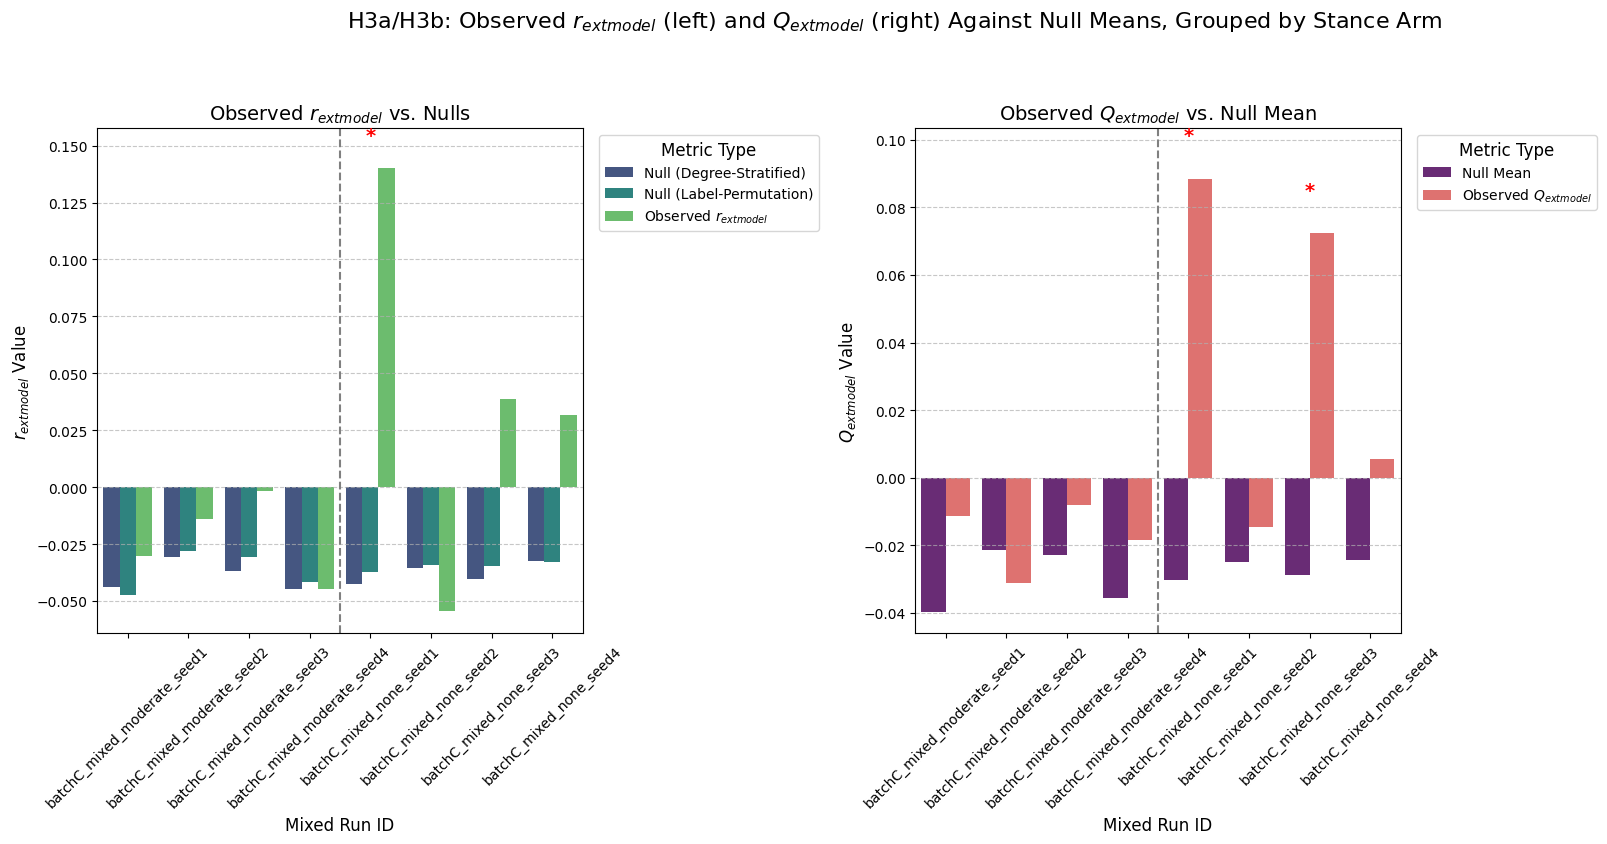

In [ ]:
# Create significance flags based on a p-value threshold of 0.05
df['is_significant_assort'] = (df['p_assort_label_null'] < 0.05) | (df['p_assort_degree_strat'] < 0.05)
df['is_significant_Q'] = (df['p_Q_label_null'] < 0.05) | (df['p_Q_degree_strat'] < 0.05)

# Prepare data for assortativity plot (left subplot)
df_assort_plot = df[['run_id', 'stance_condition', 'model_assortativity', 'null_mean_plain', 'null_mean_stratified', 'is_significant_assort']].copy()
df_assort_melted = df_assort_plot.melt(
    id_vars=['run_id', 'stance_condition', 'is_significant_assort'],
    value_vars=['model_assortativity', 'null_mean_plain', 'null_mean_stratified'],
    var_name='metric_type',
    value_name='value'
)

# Map metric types to more descriptive labels for the plot legend
metric_type_map_assort = {
    'model_assortativity': 'Observed $r_{\text{model}}$',
    'null_mean_plain': 'Null (Label-Permutation)',
    'null_mean_stratified': 'Null (Degree-Stratified)'
}
df_assort_melted['metric_type'] = df_assort_melted['metric_type'].map(metric_type_map_assort)

# Sort the DataFrame for consistent grouping and plotting, first by stance_condition
df_assort_melted = df_assort_melted.sort_values(by=['stance_condition', 'run_id', 'metric_type'])

# Prepare data for modularity (Q) plot (right subplot)
df_Q_plot = df[['run_id', 'stance_condition', 'Q_model_partition', 'Q_null_mean', 'is_significant_Q']].copy()
df_Q_melted = df_Q_plot.melt(
    id_vars=['run_id', 'stance_condition', 'is_significant_Q'],
    value_vars=['Q_model_partition', 'Q_null_mean'],
    var_name='metric_type',
    value_name='value'
)

# Map metric types to more descriptive labels for the plot legend
metric_type_map_Q = {
    'Q_model_partition': 'Observed $Q_{\text{model}}$',
    'Q_null_mean': 'Null Mean'
}
df_Q_melted['metric_type'] = df_Q_melted['metric_type'].map(metric_type_map_Q)

# Sort the DataFrame for consistent grouping and plotting, first by stance_condition
df_Q_melted = df_Q_melted.sort_values(by=['stance_condition', 'run_id', 'metric_type'])


# Set up the matplotlib figure and axes for two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8)) # 1 row, 2 columns

# --- Assortativity plot (left subplot) ---
sns.barplot(
    x='run_id',
    y='value',
    hue='metric_type',
    data=df_assort_melted,
    ax=axes[0],
    palette='viridis' # Choose a color palette
)
axes[0].set_title('Observed $r_{\text{model}}$ vs. Nulls', fontsize=14)
axes[0].set_xlabel('Mixed Run ID', fontsize=12)
axes[0].set_ylabel('$r_{\text{model}}$ Value', fontsize=12)
axes[0].tick_params(axis='x', rotation=45, labelsize=10) # Rotate x-axis labels for readability
axes[0].grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for better readability

# Add significance markers for assortativity
ordered_run_ids = df_assort_melted['run_id'].unique() # Get the order of run_ids on the x-axis
max_y_assort = axes[0].get_ylim()[1]
for i, run_id_val in enumerate(ordered_run_ids):
    # Check the significance flag for this specific run_id from the original (non-melted) dataframe
    is_sig = df_assort_plot[df_assort_plot['run_id'] == run_id_val]['is_significant_assort'].iloc[0]
    if is_sig:
        # Find the maximum value for this run_id to place the asterisk above the highest bar
        max_val = df_assort_melted[df_assort_melted['run_id'] == run_id_val]['value'].max()
        axes[0].text(
            x=i, # x-coordinate corresponds to the index of the run_id on the x-axis
            y=max_val + 0.01, # Offset slightly above the bar
            s='*', # Asterisk symbol for significance
            ha='center', # Center the asterisk horizontally
            va='bottom', # Align the asterisk to the bottom of the text bounding box
            color='red',
            fontsize=14,
            weight='bold'
        )
        # Update max_y_assort if the asterisk goes higher
        if max_val + 0.01 > max_y_assort:
            max_y_assort = max_val + 0.01

# Adjust y-axis limit for assortativity plot
axes[0].set_ylim(top=max_y_assort * 1.05) # Add 5% padding to the top

# Add vertical lines to visually separate 'stance_condition' groups
stance_conditions_order = df_assort_melted['stance_condition'].unique()
if len(stance_conditions_order) > 1:
    current_stance = stance_conditions_order[0]
    for i, run_id_val in enumerate(ordered_run_ids):
        # Check if the stance_condition changes at this run_id
        if df_assort_plot[df_assort_plot['run_id'] == run_id_val]['stance_condition'].iloc[0] != current_stance:
            # Draw a vertical line before the new stance_condition group starts
            axes[0].axvline(x=i - 0.5, color='gray', linestyle='--', linewidth=1.5)
            axes[1].axvline(x=i - 0.5, color='gray', linestyle='--', linewidth=1.5) # Add line to the second plot as well
            current_stance = df_assort_plot[df_assort_plot['run_id'] == run_id_val]['stance_condition'].iloc[0]

axes[0].legend(title='Metric Type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10, title_fontsize=12)


# --- Modularity (Q) plot (right subplot) ---
sns.barplot(
    x='run_id',
    y='value',
    hue='metric_type',
    data=df_Q_melted,
    ax=axes[1],
    palette='magma' # Choose a different color palette
)
axes[1].set_title('Observed $Q_{\text{model}}$ vs. Null Mean', fontsize=14)
axes[1].set_xlabel('Mixed Run ID', fontsize=12)
axes[1].set_ylabel('$Q_{\text{model}}$ Value', fontsize=12)
axes[1].tick_params(axis='x', rotation=45, labelsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Add significance markers for modularity (Q)
ordered_run_ids_Q = df_Q_melted['run_id'].unique() # Should be the same order as for assortativity
max_y_Q = axes[1].get_ylim()[1]
for i, run_id_val in enumerate(ordered_run_ids_Q):
    is_sig = df_Q_plot[df_Q_plot['run_id'] == run_id_val]['is_significant_Q'].iloc[0]
    if is_sig:
        max_val = df_Q_melted[df_Q_melted['run_id'] == run_id_val]['value'].max()
        axes[1].text(
            x=i,
            y=max_val + 0.01,
            s='*', # Asterisk symbol for significance
            ha='center',
            va='bottom',
            color='red',
            fontsize=14,
            weight='bold'
        )
        # Update max_y_Q if the asterisk goes higher
        if max_val + 0.01 > max_y_Q:
            max_y_Q = max_val + 0.01

# Adjust y-axis limit for modularity (Q) plot
axes[1].set_ylim(top=max_y_Q * 1.05) # Add 5% padding to the top

axes[1].legend(title='Metric Type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10, title_fontsize=12)

# Overall title for the entire figure
plt.suptitle('H3a/H3b: Observed $r_{\text{model}}$ (left) and $Q_{\text{model}}$ (right) Against Null Means, Grouped by Stance Arm',
             fontsize=16, y=1.05) # Adjust y to give enough space for the title

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to prevent legends and suptitle from overlapping
plt.show()

In [ ]:
h3_style = pd.read_csv("/content/drive/MyDrive/thesis/code/h3_stylometry.csv")

In [ ]:
h3_style.head()

,variant,grouping,group_col,n_groups,macro_f1,balanced_accuracy,null_macro_f1,p_value,n_samples,error
0,all features (grouped by agent),agent,agent_uid,685.0,0.900566,0.901794,0.330549,0.009901,2622.0,NaN
1,no length features,agent,agent_uid,685.0,0.896367,0.898148,0.330614,0.009901,2622.0,NaN
2,length-matched,agent,agent_uid,685.0,0.895145,0.896249,0.330989,0.009901,2622.0,NaN
3,no punctuation features,agent,agent_uid,685.0,0.892857,0.894727,0.330945,0.009901,2622.0,NaN
4,all features (grouped by RUN),run,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8 run group(s) carry more than one model label...


In [ ]:
h3_ablation_core = pd.read_csv("/content/drive/MyDrive/thesis/code/h3_family_ablation_core.csv")

h3_ablation_sensitivity = pd.read_csv("/content/drive/MyDrive/thesis/code/h3_family_ablation_sensitivity.csv")

In [ ]:
h3_ablation_core.head()

,analysis,family,level,macro_f1,balanced_accuracy,null_macro_f1,f1_above_null,p_value,n_features_max,unique_contribution,q_value_BH
0,alone,surface_stylometry,surface,0.886880,0.889814,0.328937,0.557943,0.016393,135,NaN,0.016393
1,alone,raw_surface,surface,0.582544,0.603381,0.325894,0.256650,0.016393,17,NaN,0.016393
2,alone,lexical_style,lexical,0.483519,0.498046,0.314376,0.169143,0.016393,2,NaN,0.016393
3,alone,pos,syntactic,0.821129,0.824580,0.329585,0.491544,0.016393,31,NaN,0.016393
4,alone,discourse,discourse,0.549672,0.564360,0.325622,0.224050,0.016393,11,NaN,0.016393


In [ ]:
h3_ablation_sensitivity.head()

,variant,added,macro_f1,balanced_accuracy,null_macro_f1,f1_above_null,p_value,n_features_max,delta_vs_core,length_matched
0,CORE only,-,0.903224,0.904169,0.327937,0.575287,0.016393,196,NaN,NaN
1,CORE + dependency,dependency,0.911472,0.912175,0.328061,0.583411,0.016393,225,0.008247,NaN
2,CORE + clause_complexity,clause_complexity,0.906185,0.907321,0.328919,0.577266,0.016393,209,0.002961,NaN
3,CORE + char_ngram,char_ngram,0.910136,0.910363,0.330761,0.579375,0.016393,3196,0.006912,NaN
4,CORE + social_markup,social_markup,0.900126,0.900916,0.327899,0.572226,0.016393,200,-0.003098,NaN


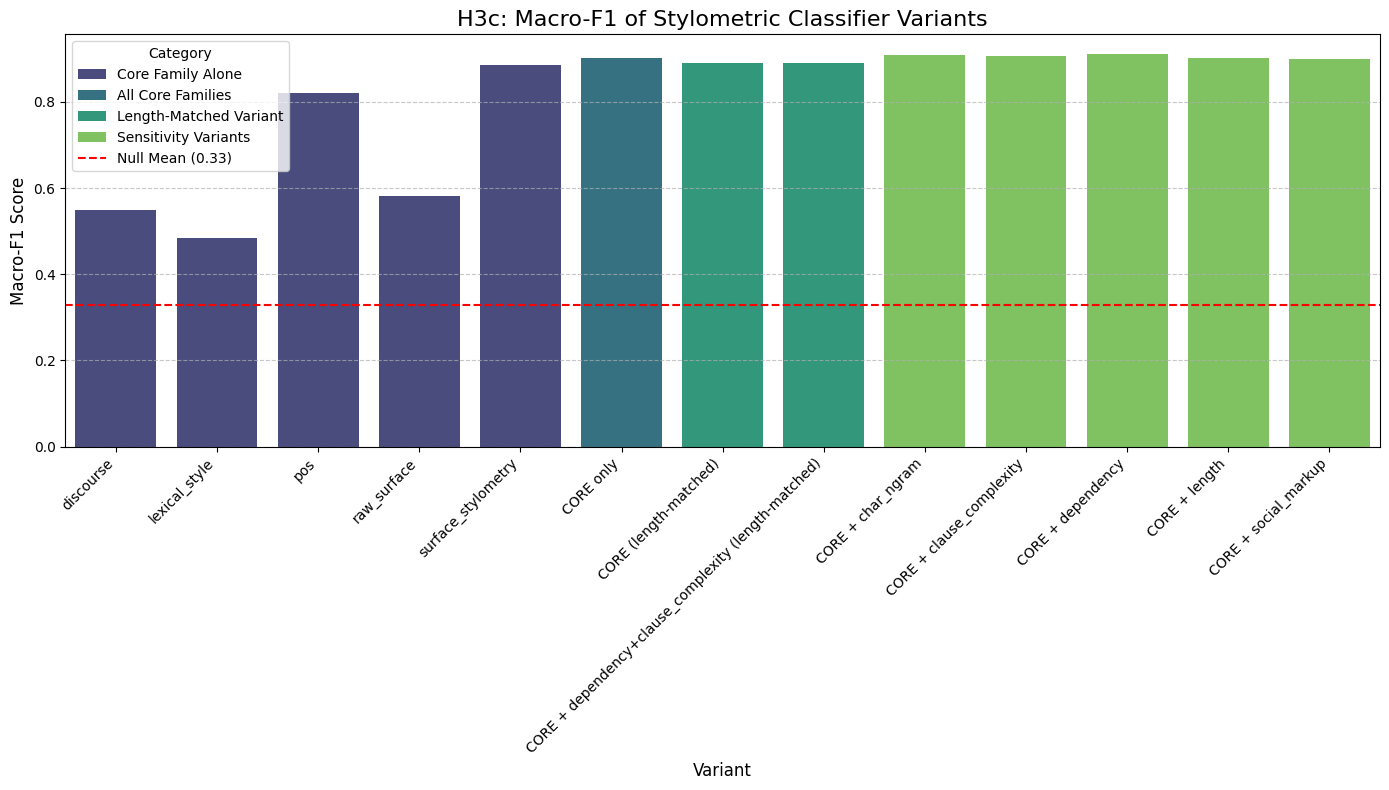

In [ ]:


# 1. Prepare data for 'each core family alone'
core_alone_data = h3_ablation_core[h3_ablation_core['analysis'] == 'alone'].copy()
core_alone_data = core_alone_data[['family', 'macro_f1']]
core_alone_data.rename(columns={'family': 'label'}, inplace=True)
core_alone_data['category'] = 'Core Family Alone'

# 2. Prepare data for 'all core families'
all_core_data = h3_ablation_sensitivity[h3_ablation_sensitivity['variant'] == 'CORE only'].copy()
null_mean_reference = all_core_data['null_macro_f1'].iloc[0] # Get the null mean for reference line
all_core_data = all_core_data[['variant', 'macro_f1']]
all_core_data.rename(columns={'variant': 'label'}, inplace=True)
all_core_data['category'] = 'All Core Families'

# 3. Prepare data for 'length-matched variant'
length_matched_data = h3_ablation_sensitivity[h3_ablation_sensitivity['length_matched'] == True].copy()
length_matched_data = length_matched_data[['variant', 'macro_f1']]
length_matched_data.rename(columns={'variant': 'label'}, inplace=True)
length_matched_data['category'] = 'Length-Matched Variant'

# 4. Prepare data for 'sensitivity variants'
# Exclude 'CORE only' and 'length-matched' from sensitivity variants
sensitivity_data = h3_ablation_sensitivity[
    (h3_ablation_sensitivity['variant'] != 'CORE only') &
    (h3_ablation_sensitivity['length_matched'] != True)
].copy()
sensitivity_data = sensitivity_data[['variant', 'macro_f1']]
sensitivity_data.rename(columns={'variant': 'label'}, inplace=True)
sensitivity_data['category'] = 'Sensitivity Variants'

# Combine all dataframes
plot_df = pd.concat([core_alone_data, all_core_data, length_matched_data, sensitivity_data], ignore_index=True)

# Define a specific order for categories to ensure consistent plotting
category_order = [
    'Core Family Alone',
    'All Core Families',
    'Length-Matched Variant',
    'Sensitivity Variants'
]
plot_df['category'] = pd.Categorical(plot_df['category'], categories=category_order, ordered=True)

# Sort the DataFrame for consistent plotting within categories
plot_df = plot_df.sort_values(by=['category', 'label'])

# Create the plot
plt.figure(figsize=(14, 8))
sns.barplot(data=plot_df, x='label', y='macro_f1', hue='category', dodge=False, palette='viridis')

# Add the reference line for the permuted-label null mean
plt.axhline(y=null_mean_reference, color='red', linestyle='--', label=f'Null Mean ({null_mean_reference:.2f})')

plt.title('H3c: Macro-F1 of Stylometric Classifier Variants', fontsize=16)
plt.xlabel('Variant', fontsize=12)
plt.ylabel('Macro-F1 Score', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate x-axis labels for readability
plt.legend(title='Category')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
h1_temportal_existence = pd.read_csv("/content/drive/MyDrive/thesis/code/h1_temporal_existence.csv")

In [ ]:
h2_temportal_existence = pd.read_csv("/content/drive/MyDrive/thesis/code/h2_temporal_existence.csv")

In [ ]:
h2_temportal_existence

,model,window,component,role,mean_observed,mean_null_mean,mean_excess,n_runs_p<0.05,n_runs_tested,median_p
0,llama,early,P,primary,0.033361,0.035889,-0.002527,0,5,0.650350
1,llama,early,S,primary,0.462032,0.473200,-0.011167,2,5,0.840796
2,llama,early,N,primary,0.871766,0.837013,0.034753,5,5,0.002997
3,llama,early,NC,primary,0.563774,0.472395,0.091379,2,5,0.274725
4,llama,early,D,secondary,0.942075,0.926503,0.015572,2,5,0.057942
5,llama,late,P,primary,0.038134,0.033373,0.004761,2,5,0.316683
6,llama,late,S,primary,0.563411,0.523406,0.040005,2,5,0.059701
7,llama,late,N,primary,0.868398,0.831062,0.037336,5,5,0.000999
8,llama,late,NC,primary,0.591711,0.480295,0.111416,2,5,0.229770
9,llama,late,D,secondary,0.924247,0.903196,0.021051,1,5,0.066933


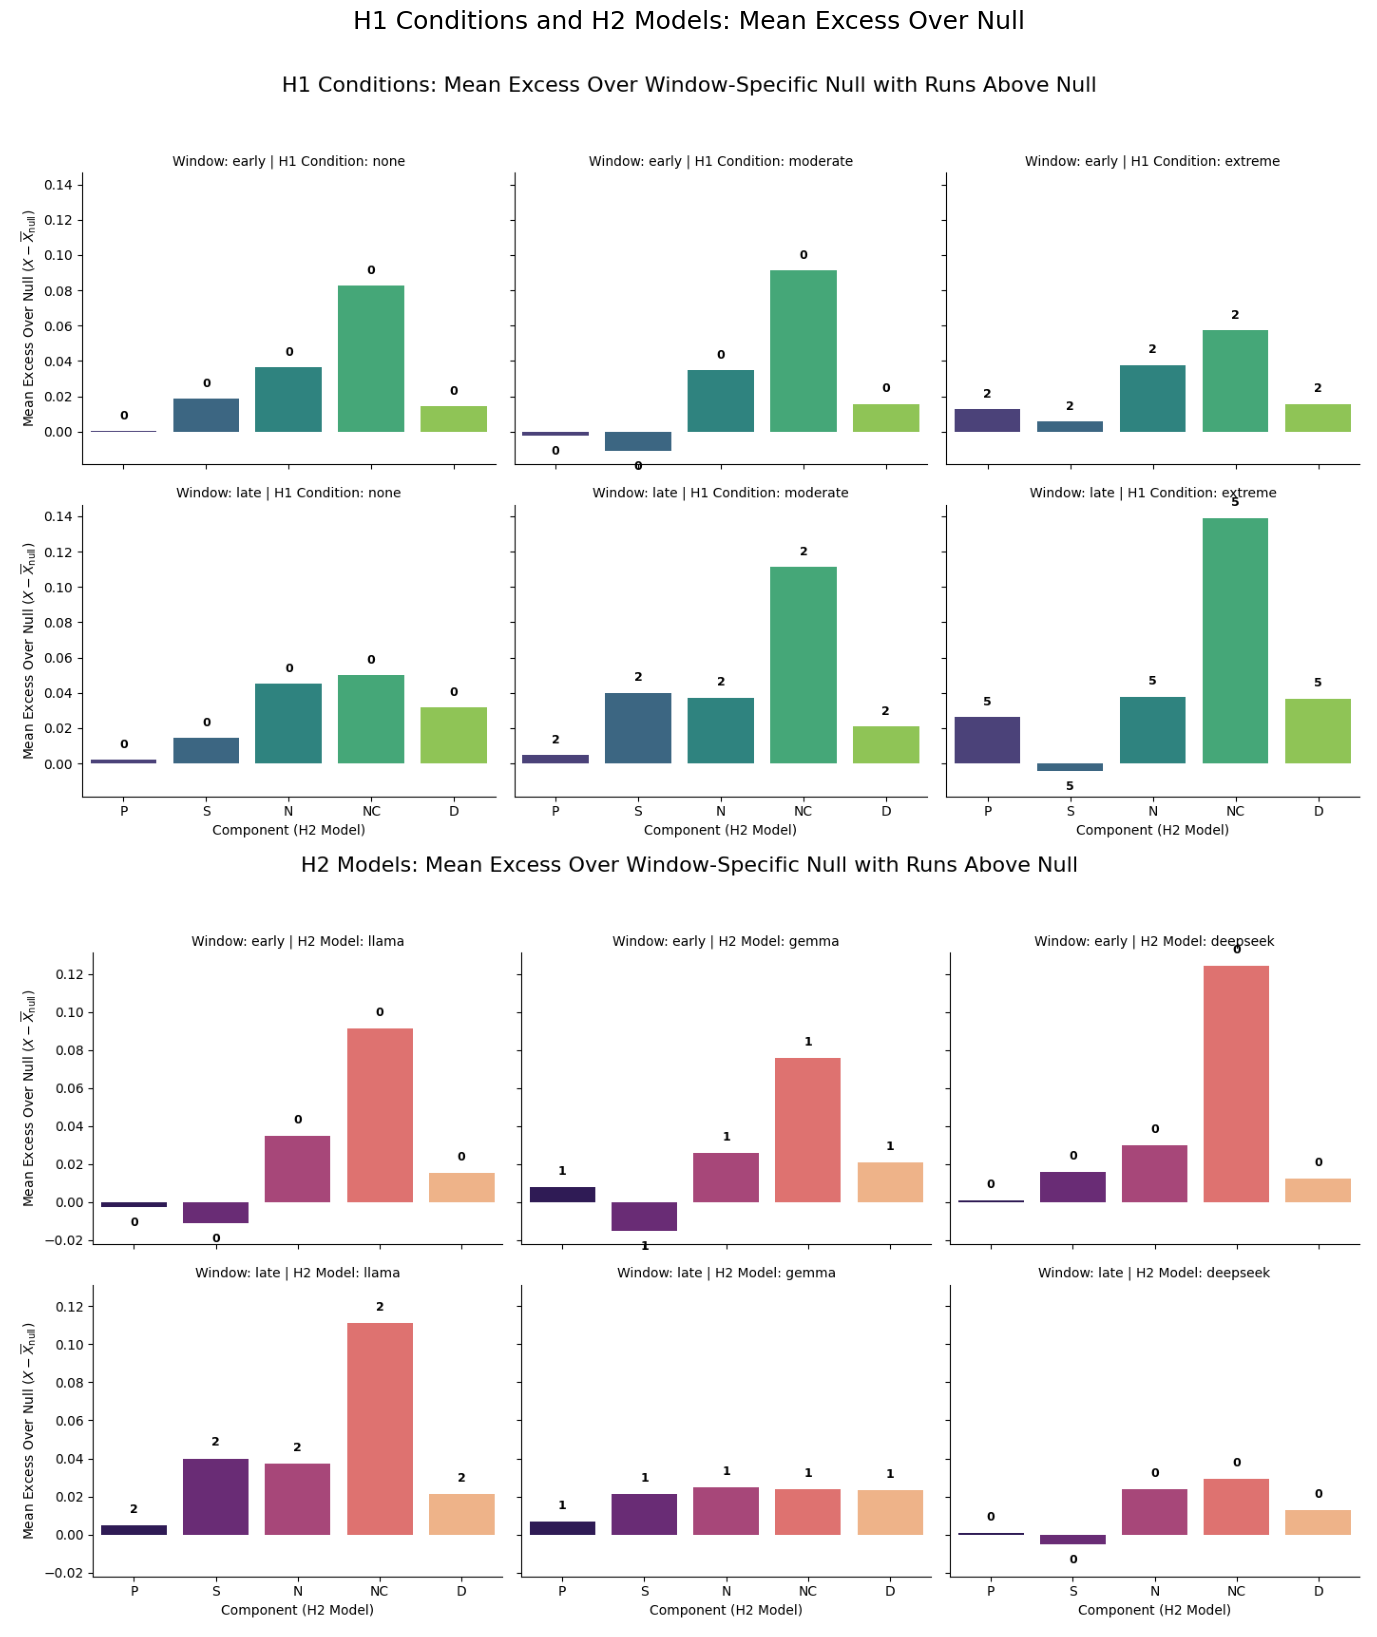

In [ ]:
# Define common orderings for components and windows
component_order = ['P', 'S', 'N', 'NC', 'D']
window_order = ['early', 'late']

# --- Plot for H1 Conditions (using h1_temportal_existence) ---

# Calculate the mean excess over the window-specific null if not already present
if 'excess_over_null' not in h1_temportal_existence.columns:
    h1_temportal_existence['excess_over_null'] = h1_temportal_existence['mean_observed'] - h1_temportal_existence['mean_null_mean']

# Define and apply categorical orders for consistent plotting
stance_condition_order = ['none', 'moderate', 'extreme']
h1_temportal_existence['component'] = pd.Categorical(h1_temportal_existence['component'], categories=component_order, ordered=True)
h1_temportal_existence['window'] = pd.Categorical(h1_temportal_existence['window'], categories=window_order, ordered=True)
h1_temportal_existence['stance_condition'] = pd.Categorical(h1_temportal_existence['stance_condition'], categories=stance_condition_order, ordered=True)

# Create the catplot for H1 conditions, faceted by stance_condition and window
g_h1 = sns.catplot(
    data=h1_temportal_existence,
    x='component',
    y='excess_over_null',
    col='stance_condition',
    row='window',
    kind='bar',
    height=4,
    aspect=1.2,
    palette='viridis',
    hue='component',
    legend=False,
    sharey=True
)

# Set axis labels and titles for H1 plot
g_h1.set_axis_labels('Component (H2 Model)', r'Mean Excess Over Null ($X - \overline{X}_{\text{null}}$)')
g_h1.set_titles(col_template='H1 Condition: {col_name}', row_template='Window: {row_name}')
g_h1.fig.suptitle('H1 Conditions: Mean Excess Over Window-Specific Null with Runs Above Null', y=1.02, fontsize=16)

# Add the number of runs above the null as text annotations on top of the bars for H1 plot
for ax_idx, ax in enumerate(g_h1.axes.flat):
    current_window = g_h1.row_names[ax_idx // len(g_h1.col_names)]
    current_stance_condition = g_h1.col_names[ax_idx % len(g_h1.col_names)]

    for i, container in enumerate(ax.containers):
        for j, bar in enumerate(container):
            current_component = component_order[j]

            # Filter the original dataframe to get the correct 'n_runs_p<0.05' column
            runs_above = h1_temportal_existence[
                (h1_temportal_existence['component'] == current_component) &
                (h1_temportal_existence['window'] == current_window) &
                (h1_temportal_existence['stance_condition'] == current_stance_condition)
            ]['n_runs_p<0.05'].iloc[0] # Using the identified column

            y = bar.get_height()
            x = bar.get_x() + bar.get_width() / 2

            va = 'bottom' if y >= 0 else 'top'
            y_offset = 0.005 if y >= 0 else -0.005

            ax.text(
                x,
                y + y_offset,
                f'{int(runs_above)}',
                ha='center',
                va=va,
                color='black',
                fontsize=9,
                weight='bold'
            )

# Save H1 plot to a BytesIO object
h1_buffer = BytesIO()
g_h1.fig.tight_layout(rect=[0, 0, 1, 0.98]) # Apply tight_layout to the FacetGrid's figure
g_h1.fig.savefig(h1_buffer, format='png', bbox_inches='tight')
plt.close(g_h1.fig) # Close the figure to free up memory and prevent it from being displayed separately
h1_buffer.seek(0)
h1_image = Image.open(h1_buffer)

# --- Plot for H2 Models (using h2_temportal_existence) ---

# Calculate the mean excess over the window-specific null if not already present
if 'excess_over_null' not in h2_temportal_existence.columns:
    h2_temportal_existence['excess_over_null'] = h2_temportal_existence['mean_observed'] - h2_temportal_existence['mean_null_mean']

# Define and apply categorical orders for consistent plotting
model_order = ['llama', 'gemma', 'deepseek'] # Assuming these are the models present
h2_temportal_existence['component'] = pd.Categorical(h2_temportal_existence['component'], categories=component_order, ordered=True)
h2_temportal_existence['window'] = pd.Categorical(h2_temportal_existence['window'], categories=window_order, ordered=True)
h2_temportal_existence['model'] = pd.Categorical(h2_temportal_existence['model'], categories=model_order, ordered=True)

# Create the catplot for H2 models, faceted by model and window
g_h2 = sns.catplot(
    data=h2_temportal_existence,
    x='component',
    y='excess_over_null',
    col='model',
    row='window',
    kind='bar',
    height=4,
    aspect=1.2,
    palette='magma',
    hue='component',
    legend=False,
    sharey=True
)

# Set axis labels and titles for H2 plot
g_h2.set_axis_labels('Component (H2 Model)', r'Mean Excess Over Null ($X - \overline{X}_{\text{null}}$)')
g_h2.set_titles(col_template='H2 Model: {col_name}', row_template='Window: {row_name}')
g_h2.fig.suptitle('H2 Models: Mean Excess Over Window-Specific Null with Runs Above Null', y=1.02, fontsize=16)

# Add the number of runs above the null as text annotations on top of the bars for H2 plot
for ax_idx, ax in enumerate(g_h2.axes.flat):
    current_window = g_h2.row_names[ax_idx // len(g_h2.col_names)]
    current_model = g_h2.col_names[ax_idx % len(g_h2.col_names)]

    for i, container in enumerate(ax.containers):
        for j, bar in enumerate(container):
            current_component = component_order[j]

            # Filter the original dataframe to get the correct 'n_runs_p<0.05' column
            runs_above = h2_temportal_existence[
                (h2_temportal_existence['component'] == current_component) &
                (h2_temportal_existence['window'] == current_window) &
                (h2_temportal_existence['model'] == current_model)
            ]['n_runs_p<0.05'].iloc[0] # Using the identified column

            y = bar.get_height()
            x = bar.get_x() + bar.get_width() / 2

            va = 'bottom' if y >= 0 else 'top'
            y_offset = 0.005 if y >= 0 else -0.005

            ax.text(
                x,
                y + y_offset,
                f'{int(runs_above)}',
                ha='center',
                va=va,
                color='black',
                fontsize=9,
                weight='bold'
            )

# Save H2 plot to a BytesIO object
h2_buffer = BytesIO()
g_h2.fig.tight_layout(rect=[0, 0, 1, 0.98]) # Apply tight_layout to the FacetGrid's figure
g_h2.fig.savefig(h2_buffer, format='png', bbox_inches='tight')
plt.close(g_h2.fig) # Close the figure to free up memory and prevent it from being displayed separately
h2_buffer.seek(0)
h2_image = Image.open(h2_buffer)

# Combine the two images into a single figure
# Determine combined width and height (stacking vertically)
combined_width = max(h1_image.width, h2_image.width)
combined_height = h1_image.height + h2_image.height

# Create a new blank image with white background
combined_image = Image.new('RGB', (combined_width, combined_height), (255, 255, 255))

# Paste the individual images onto the combined image
combined_image.paste(h1_image, (0, 0))
combined_image.paste(h2_image, (0, h1_image.height))

# Display the combined image in matplotlib
plt.figure(figsize=(combined_width / 100, combined_height / 100), dpi=100) # Adjust figsize based on image size and DPI
plt.imshow(combined_image)
plt.axis('off') # Hide axes for the image display
plt.title('H1 Conditions and H2 Models: Mean Excess Over Null', fontsize=18, y=1.02) # Add a main title for the combined plot
plt.tight_layout()
plt.show()